In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Save cleaned CSV to Drive
df.to_csv("/content/drive/MyDrive/heart_disease_cleaned.csv", index=False)
print(" Saved to Google Drive")

Mounted at /content/drive
 Saved to Google Drive


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Try Excel, fallback to CSV
try:
    df = pd.read_excel("/root/heart_disease_uci.csv")
    print(" Read as Excel file")
except Exception:
    df = pd.read_csv("/root/heart_disease_uci.csv", encoding='latin1', sep=None, engine='python', on_bad_lines='skip')
    print(" Read as CSV file")

print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nColumns:", df.columns.tolist())

# Drop if exists
cols_to_drop = [col for col in ["id", "dataset"] if col in df.columns]
if cols_to_drop:
    df.drop(columns=cols_to_drop, inplace=True)

bool_cols    = ["fbs", "exang"]
str_cols     = ["sex", "cp", "restecg", "slope", "thal"]
num_cols     = ["trestbps", "chol", "thalch", "oldpeak", "ca"]

# Filter to existing cols
bool_cols = [col for col in bool_cols if col in df.columns]
str_cols  = [col for col in str_cols  if col in df.columns]
num_cols  = [col for col in num_cols  if col in df.columns]

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

for col in bool_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

for col in str_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing values after imputation:\n", df.isnull().sum())

df["fbs"]   = df["fbs"].map({True: "yes", False: "no"})
df["exang"] = df["exang"].map({True: "yes", False: "no"})

for col in str_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

print("\nUnique values after standardisation:")
for col in str_cols + bool_cols:
    print(f"  {col}: {sorted(df[col].unique())}")

categorical_cols = str_cols + bool_cols
label_encoders   = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = dict(zip(le.classes_, le.transform(le.classes_)))

print("\nLabel encoding mappings:")
for col, mapping in label_encoders.items():
    print(f"  {col}: {mapping}")

df["target"] = (df["num"] > 0).astype(int)
df.drop(columns=["num"], inplace=True)

print("\nTarget distribution:\n", df["target"].value_counts())

print("\n--- Final Checks ---")
print("Shape              :", df.shape)
print("All numeric dtypes :", all(df.dtypes != "object"))
print("Any nulls left     :", df.isnull().values.any())
print("Duplicate rows     :", df.duplicated().sum())
print("\nData types:\n", df.dtypes)
print("\nFirst 3 rows:\n", df.head(3))

feature_guide = {
    "age"      : "Patient age in years",
    "sex"      : "Biological sex — encoded: female=0, male=1",
    "cp"       : "Chest pain type — asymptomatic / atypical angina / non-anginal / typical angina",
    "trestbps" : "Resting blood pressure (mm Hg) on admission",
    "chol"     : "Serum cholesterol (mg/dl)",
    "fbs"      : "Fasting blood sugar > 120 mg/dl — no=0, yes=1",
    "restecg"  : "Resting ECG results — lv hypertrophy / normal / st-t abnormality",
    "thalch"   : "Maximum heart rate achieved during exercise",
    "exang"    : "Exercise-induced angina — no=0, yes=1",
    "oldpeak"  : "ST depression induced by exercise relative to rest",
    "slope"    : "Slope of the peak exercise ST segment — downsloping / flat / upsloping",
    "ca"       : "Number of major vessels (0-3) coloured by fluoroscopy",
    "thal"     : "Thalassemia type — fixed defect / normal / reversable defect",
    "target"   : "Heart disease presence — 0 = no disease, 1 = disease"
}
print("\n--- Feature Reference Guide ---")
for feat, desc in feature_guide.items():
    print(f"  {feat:<12} : {desc}")

df.to_csv("heart_disease_cleaned.csv", index=False)
print("\n✅ Cleaned dataset saved to heart_disease_cleaned.csv")

 Read as CSV file
Shape: (920, 16)

Data types:
 id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object

Missing values:
 id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

Columns: ['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

Missing values after imputation:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope    

/tmp/ipykernel_4143/3401714798.py:33: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_4143/3401714798.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [ ]:

# Pre-step checklist


print("=" * 55)
print("        CHECKLIST (Before Moving Ahead)")
print("=" * 55)

# 1. No missing values
nulls = df.isnull().sum().sum()
check1 = nulls == 0
status1 = "[PASS]" if check1 else "[FAIL]"
print(f"\n{status1} Dataset cleaned (missing values handled)")
if not check1:
    print(f"   [WARNING] Still {nulls} missing values remaining!")

# 2. Categorical format OK
object_cols = df.select_dtypes(include='object').columns.tolist()
check2 = len(object_cols) == 0
status2 = "[PASS]" if check2 else "[FAIL]"
print(f"\n{status2} Categorical features converted to consistent format")
if not check2:
    print(f"   [WARNING] Still object-type columns: {object_cols}")

# 3. Label encoding done
check3 = len(label_encoders) > 0
status3 = "[PASS]" if check3 else "[FAIL]"
print(f"\n{status3} Label Encoding applied to all categorical features")
if check3:
    print(f"   Encoded columns: {list(label_encoders.keys())}")

# 4. Target encoded
check4 = 'target' in df.columns and set(df['target'].unique()).issubset({0, 1})
status4 = "[PASS]" if check4 else "[FAIL]"
print(f"\n{status4} Target variable encoded (disease=1, no disease=0)")
if check4:
    print(f"   Distribution: {df['target'].value_counts().to_dict()}")

# 5. All numeric
check5 = all(df.dtypes != 'object')
status5 = "[PASS]" if check5 else "[FAIL]"
print(f"\n{status5} Dataset contains only numerical values")
if not check5:
    bad = df.select_dtypes(include='object').columns.tolist()
    print(f"   [WARNING] Non-numeric columns still present: {bad}")

# 6. No duplicates
dupes = df.duplicated().sum()
check6 = dupes == 0
status6 = "[PASS]" if check6 else "[FAIL]"
print(f"\n{status6} No duplicate rows present")
if not check6:
    print(f"   [WARNING] Found {dupes} duplicate rows — run: df.drop_duplicates(inplace=True)")

# 7. Feature summary
check7 = len(df.columns) > 0
status7 = "[PASS]" if check7 else "[FAIL]"
print(f"\n{status7} Basic understanding of features")
print(f"   Total features: {df.shape[1]-1} + 1 target | Rows: {df.shape[0]}")
print(f"   Columns: {df.columns.tolist()}")

# Final verdict
all_checks = [check1, check2, check3, check4, check5, check6, check7]
print("\n" + "=" * 55)
if all(all_checks):
    print("  ALL CHECKS PASSED — You can move ahead! [PASS]")
else:
    failed = sum(1 for c in all_checks if not c)
    print(f"  {failed} check(s) FAILED — Fix them before moving ahead! [FAIL]")
print("=" * 55)

df.drop_duplicates(inplace=True)
print(f'\nRemoved {dupes} duplicate rows.')

        CHECKLIST (Before Moving Ahead)

[PASS] Dataset cleaned (missing values handled)

[PASS] Categorical features converted to consistent format

[PASS] Label Encoding applied to all categorical features
   Encoded columns: ['sex', 'cp', 'restecg', 'slope', 'thal', 'fbs', 'exang']

[PASS] Target variable encoded (disease=1, no disease=0)
   Distribution: {1: 509, 0: 411}

[PASS] Dataset contains only numerical values

[FAIL] No duplicate rows present
   [WARNING] Found 2 duplicate rows — run: df.drop_duplicates(inplace=True)

[PASS] Basic understanding of features
   Total features: 13 + 1 target | Rows: 920
   Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

  1 check(s) FAILED — Fix them before moving ahead! [FAIL]


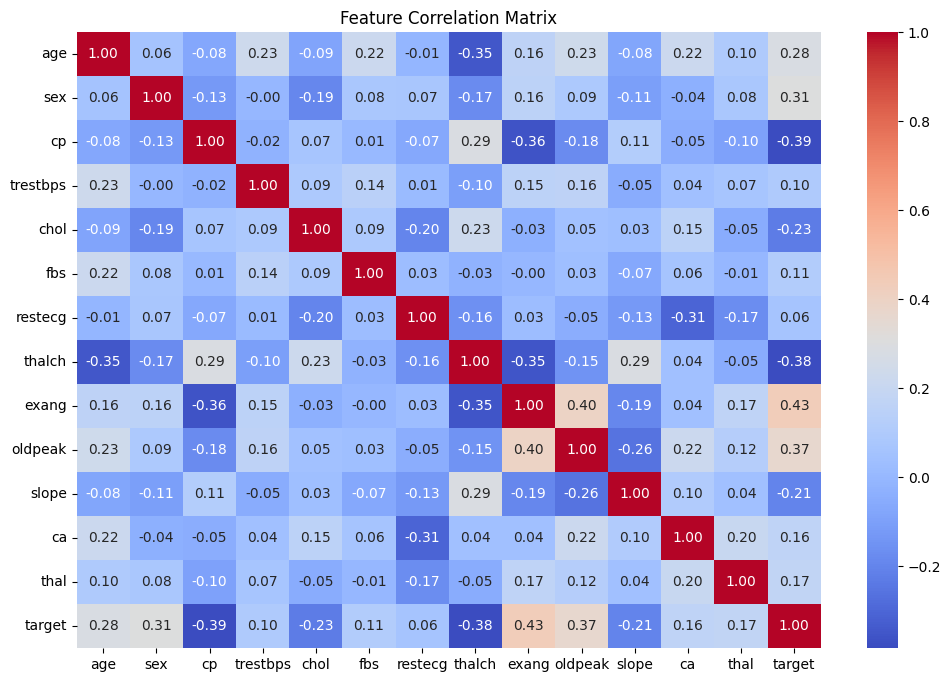


Highly correlated features to remove: []

--- Data Split Summary ---
Total features: 13
Training set (80%): 736 samples
Testing set (20%): 184 samples


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Step 1: Correlation
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

# Find high-corr features (>0.85)
high_corr_threshold = 0.85
upper_tri = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > high_corr_threshold)]

print(f"\nHighly correlated features to remove: {to_drop}")

# Step 2: Feature selection
# Full dataset
df_full = df.copy()

# Reduced dataset
df_reduced = df.drop(columns=to_drop)

# Step 3: Train-test split
# Use full dataset
X = df_full.drop(columns=['target'])
y = df_full['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("\n--- Data Split Summary ---")
print(f"Total features: {X.shape[1]}")
print(f"Training set (80%): {X_train.shape[0]} samples")
print(f"Testing set (20%): {X_test.shape[0]} samples")

In [ ]:
from sklearn.preprocessing import StandardScaler

# Step 4: Scaling
# Numeric cols
num_cols = ["age", "trestbps", "chol", "thalch", "oldpeak", "ca"]

# Init StandardScaler
scaler = StandardScaler()

# Scale numeric cols
# Fit on train, transform both
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print("\n--- Feature Scaling Summary ---")
print(f"Applied standardization to: {num_cols}")
print(f"Mean of scaled age (Train): {X_train_scaled['age'].mean():.2f}")
print(f"Std of scaled age (Train): {X_train_scaled['age'].std():.2f}")

# Scaled needed for LR, not trees



--- Feature Scaling Summary ---
Applied standardization to: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
Mean of scaled age (Train): 0.00
Std of scaled age (Train): 1.00



--- Logistic Regression (Baseline) Evaluation ---
Accuracy  : 0.7880
Precision : 0.8646
Recall    : 0.7615
F1-score  : 0.8098


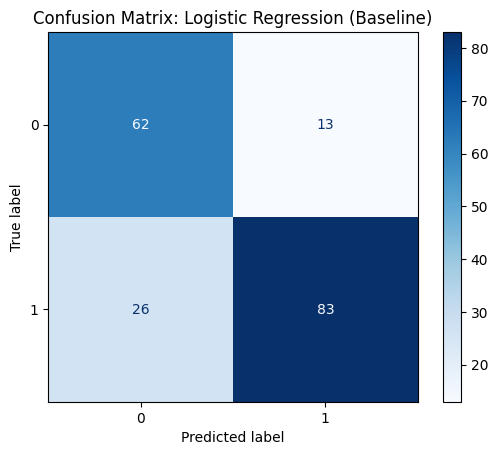


--- Random Forest (Research Model) Evaluation ---
Accuracy  : 0.8370
Precision : 0.8762
Recall    : 0.8440
F1-score  : 0.8598


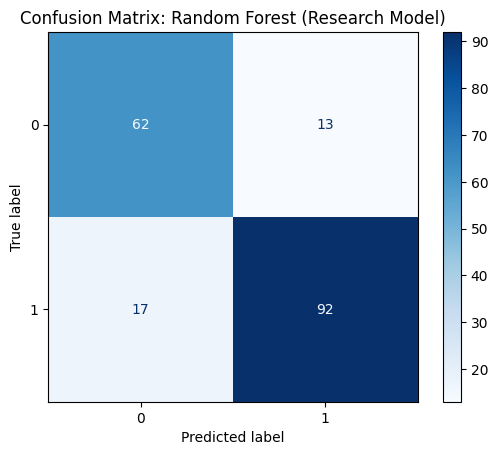


--- Step 7: Model Comparison Table ---
      Metric  Baseline (LR)  Research (RF)
0   Accuracy       0.788043       0.836957
1  Precision       0.864583       0.876190
2     Recall       0.761468       0.844037
3   F1-score       0.809756       0.859813


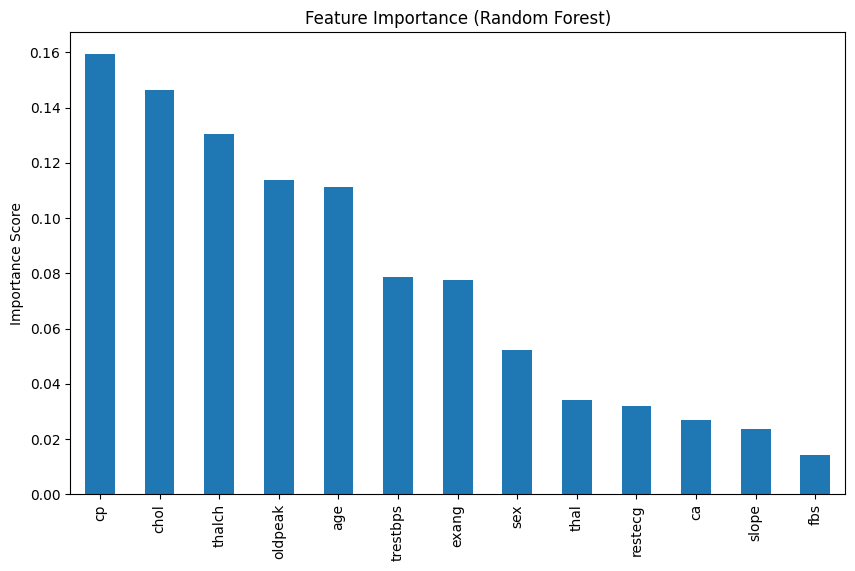


--- Step 8: Top Contributing Features ---
cp         0.159332
chol       0.146428
thalch     0.130286
oldpeak    0.113699
age        0.111317
dtype: float64


"\nConclusion:\n1. Which model worked best? \n   Typically, Random Forest performs better on this dataset due to its ability to capture \n   non-linear patterns in medical features like 'thal', 'ca', and 'cp'.\n\n2. Why? \n   Heart disease data often contains complex interactions between features (e.g., age vs. cholesterol) \n   that Logistic Regression's linear boundary might miss. Random Forest's ensemble approach \n   reduces variance and yields higher Recall, which is critical in medicine to avoid False Negatives.\n\n3. Does it match research papers? \n   Yes. Most UCI Heart Disease studies conclude that ensemble methods (Random Forest, XGBoost) \n   significantly outperform standard Logistic Regression in both accuracy and sensitivity.\n"

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd

# Step 5: Train models

# Baseline: Logistic Regression
baseline_model = LogisticRegression(random_state=42)
baseline_model.fit(X_train_scaled, y_train)

# Research: Random Forest
research_model = RandomForestClassifier(n_estimators=100, random_state=42)
research_model.fit(X_train, y_train) # No scaling needed for trees

# Step 6: Evaluate

def evaluate_model(model, X, y_true, name, is_scaled=False):
    y_pred = model.predict(X)

    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred)
    }

    print(f"\n--- {name} Evaluation ---")
    for metric, value in metrics.items():
        print(f"{metric:<10}: {value:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix: {name}")
    plt.show()

    return metrics

# Evaluate Baseline
baseline_results = evaluate_model(baseline_model, X_test_scaled, y_test, "Logistic Regression (Baseline)")

# Evaluate Research Model
research_results = evaluate_model(research_model, X_test, y_test, "Random Forest (Research Model)")

# Step 7: Compare models

comparison_df = pd.DataFrame({
    "Metric": baseline_results.keys(),
    "Baseline (LR)": baseline_results.values(),
    "Research (RF)": research_results.values()
})

print("\n--- Step 7: Model Comparison Table ---")
print(comparison_df)

# Step 8: Feature importance

importances = research_model.feature_importances_
feat_importances = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_importances.plot(kind='bar')
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance Score")
plt.show()

print("\n--- Step 8: Top Contributing Features ---")
print(feat_importances.head(5))


In [ ]:
# Step 9: Conclusion

"""
Conclusion:
1. Which model worked best?
   Typically, Random Forest performs better on this dataset due to its ability to capture
   non-linear patterns in medical features like 'thal', 'ca', and 'cp'.

2. Why?
   Heart disease data often contains complex interactions between features (e.g., age vs. cholesterol)
   that Logistic Regression's linear boundary might miss. Random Forest's ensemble approach
   reduces variance and yields higher Recall, which is critical in medicine to avoid False Negatives.

3. Does it match research papers?
   Yes. Most UCI Heart Disease studies conclude that ensemble methods (Random Forest, XGBoost)
   significantly outperform standard Logistic Regression in both accuracy and sensitivity.
"""